In [64]:
import numpy as np
from matplotlib import pyplot as plt
from RVSS_EOS_Slope import RVSS_EOS_Slope as rvss_eos
from Modules.TOV_Solver_RK45 import TovSolverRK45 as tov_solver
from scipy.interpolate import interp1d,PchipInterpolator
import kuibit.simdir as SD
import bisect
import os
import glob
from matplotlib import pyplot as plt
from scipy.stats import linregress,sem
from scipy.stats import t
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
from scipy.interpolate import make_smoothing_spline
import matplotlib.cm as cm
import matplotlib.colors as colors
from Modules.eos_bar_analytic import EOS_Piecewise_Poly,load_pizza
from Modules.eos_bar_table import EOS_Table
from Modules.unitconv import *

In [2]:
#Physical Constants
c = 299792458  # Speed of light in m/s
G = 6.67430e-11  # Gravitational constant in m^3/kg/s^2
hc = 197.3 #hbar c Mev fm

freq_code_u_to_hz = 203000
mn = 939.56
n0 = 0.16
epsilon = mn*n0
kg_m3_to_MeV_fm3 = 5.605*10**(-16)
Pa_to_MeV_fm3 = 6.242*10**(-33)
R0 = 1.477 #Solar Mass to km conversion

geometrized_to_SI = c**2 / G  # Conversion factor from geometrized units to SI units (kg/m^3)
kg_to_g = 1000  # Conversion factor from kg to g
m3_to_cm3 = 1e6  # Conversion factor from m^3 to cm^3

geometrized_code_to_nb_n0 = (((geometrized_to_SI*(1/1476)**2)*kg_to_g/m3_to_cm3)/(1.6582*10**(-24)))*(1/(10**39))


In [77]:
eos_colors = {"BA": "red",
              "DD2F-SF1": "black",
              "DD2": "orange",
              "BHBlp": "green",
              "SFHo": "purple",
              "BLQ": "gold",
              "SLy4": "turquoise",
              "BLh": "darkgreen",
              "LS220": "plum",
              }

core_subeos = {"BA": "red",
              "DD2-SF1": "gold",
              "DD2": "brown",
              "BHBlp": "green",
              "BLQ": "purple",
              "BLh": "black",
              "LS220": "blue",
              "SLy4" : "plum",
              "SFHo" : "slategray",
              "MS1b": "black",
              "SLy": "blue"}


In [18]:
core_db_path = '/home/john/UW_PhD_Program/RVSS_Slope_Parametrization/coreDB/THC_DB/THC/DB'
core_db_eos_path = '/home/john/UW_PhD_Program/RVSS_Slope_Parametrization/coreDB/THC_DB/THC/DB/EOS'
sim_names = [name for name in os.listdir(core_db_path) if os.path.isdir(os.path.join(core_db_path,name)) and (name != 'EOS' and name != 'SkyNet')]
eos_list = [name for name in os.listdir(core_db_eos_path) if os.path.isdir(os.path.join(core_db_eos_path,name))]
sim_dirs = {}

sim_info = {}

i = 0

for sim in sim_names:
    sim_info[sim] = {}
    sim_name_parsed = sim.split('_')
    eos_name = sim_name_parsed[0]
    mass_1 = float(sim_name_parsed[1])
    mass_2 = float(sim_name_parsed[2])
    mass_total = mass_1 + mass_2

    sim_info[sim]['m1'] = mass_1
    sim_info[sim]['m2'] = mass_2

    sim_info[sim]['m_total'] = mass_total
    sim_info[sim]['eos'] = eos_name

 
    
    metadata = os.path.abspath(os.path.join(core_db_path,sim,'metadata.txt'))
    with open(metadata,'r') as file:
        lines = file.readlines()
        for line in lines:
            line = line.strip('\n')
            line_split = line.split(' ')
            line_split = [x for x in line_split if x]
            if len(line_split) > 0:
                if line_split[0] == 'id_kappa2T':
                    sim_info[sim]["kappa_2T"] = float(line_split[-1])
                if line_split[0] == 'id_Lambda':
                    sim_info[sim]["Lambda_2T"] = float(line_split[-1])
                if line_split[0] == 'id_spin_starA':
                    sim_info[sim]["spin1"] = [float(line_split[-3].strip(',')),float(line_split[-2].strip(',')),float(line_split[-1].strip(','))]

    kb_sim_dirs = {}

for eos in sim_names:
    kb_sim_dirs[eos] = SD.SimDir(os.path.abspath(os.path.join(core_db_path,eos)))

    
p_cut = 600

core_db_strain = {}
core_db_gws = {}
core_db_gw_phase = {}
core_db_gw_inst_freq = {}
core_db_gw_asd = {}
core_db_gw_htilde = {}

core_fpeak = {}

for sim_name in kb_sim_dirs:
    sd = kb_sim_dirs[sim_name]
    core_db_strain[sim_name] = {}
    core_db_gws[sim_name] = {}
    for gw in sd.gws:
        extr_radius = str(gw.radius)
        core_db_gws[sim_name][extr_radius] = gw
        strain = gw.get_strain_lm(2,
                                2,
                                p_cut,
                                0.1,
                                window_function='tukey')
        core_db_strain[sim_name][extr_radius] = strain

for sim in core_db_strain:
    i = i + 1
    core_db_gw_phase[sim] = {}
    core_db_gw_inst_freq[sim] = {}
    for r in core_db_strain[sim]:
        time = core_db_strain[sim][r].t
        real_h = np.real(core_db_strain[sim][r].y)
        imag_h = np.imag(core_db_strain[sim][r].y)
        phase = np.unwrap(np.arctan2(real_h,imag_h))
        
        core_db_gw_phase[sim][r] = phase
        core_db_gw_inst_freq[sim][r] = (1/(2*np.pi))*np.gradient(phase,time)
    
    core_db_gw_asd[sim] = {}
    core_db_gw_htilde[sim] = {}
    for r in core_db_strain[sim]:
        h_plus = core_db_strain[sim][r].real()
        h_cross = core_db_strain[sim][r].imag()

        h_plus_tilde = h_plus.to_FrequencySeries()
        h_cross_tilde = h_cross.to_FrequencySeries()

        h_tilde = np.sqrt((h_plus_tilde.real()**2 + h_plus_tilde.imag()**2) + (h_cross_tilde.real()**2 + h_cross_tilde.imag()**2))
        core_db_gw_htilde[sim][r] = h_tilde
        core_db_gw_asd[sim][r] = 2.0*h_tilde.fft*np.sqrt(h_tilde.f*freq_code_u_to_hz)
    core_fpeak[sim] = core_db_gw_htilde[sim]['400.0'].f[np.argmax(core_db_gw_asd[sim]['400.0'])]*freq_code_u_to_hz/1000
    sim_info[sim]['Mfpeak'] = (core_db_gw_htilde[sim]['400.0'].f[np.argmax(core_db_gw_asd[sim]['400.0'])])*(sim_info[sim]['m_total'])
    sim_info[sim]['fpeak'] = core_fpeak[sim]
print(i)


<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0

/home/john/.local/lib/python3.10/site-packages/kuibit/timeseries.py:769: RuntimeWarning: TimeSeries is not regularly samples. Resampling.
  warnings.warn(


<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0x737a325a32e0>
<function tukey at 0

In [69]:
uc = PIZZA_UNITS
SLy4_Data = np.loadtxt('/home/john/UW_PhD_Program/RVSS_Slope_Parametrization/coreDB/THC_DB/THC/DB/EOS/SLy4/eos.pizza',skiprows=5)
SLy4_RMD = SLy4_Data[:,0]

SLy_eos = load_pizza('/home/john/UW_PhD_Program/RVSS_Slope_Parametrization/coreDB/THC_DB/THC/DB/EOS/SLy/eos.pizza')
MS1b_eos = load_pizza('/home/john/UW_PhD_Program/RVSS_Slope_Parametrization/coreDB/THC_DB/THC/DB/EOS/MS1b/eos.pizza')
SLy_RMD = SLy4_RMD/uc.density
print(SLy_RMD)
SLy_sed = np.array([SLy_eos._sed_from_rmd(rho) for rho in SLy_RMD])
SLy_csnd = np.array([SLy_eos._csnd_from_rmd(rho) for rho in SLy_RMD])
SLy_press = np.array([SLy_eos.p_from_rmd(rho) for rho in SLy_RMD])

SLy_Table = EOS_Table(SLy_RMD,SLy_sed,SLy_press,SLy_csnd,isentropic='True') 
SLy_Table.save_pizza('./Data/SLy.pizza')

MS1b_RMD = SLy4_RMD/uc.density
MS1b_sed = np.array([MS1b_eos._sed_from_rmd(rho) for rho in MS1b_RMD])
MS1b_csnd = np.array([MS1b_eos._csnd_from_rmd(rho) for rho in MS1b_RMD])
MS1b_press = np.array([MS1b_eos.p_from_rmd(rho) for rho in MS1b_RMD])
MS1b_Table = EOS_Table(MS1b_RMD, MS1b_sed, MS1b_press, MS1b_csnd, isentropic='True')
MS1b_Table.save_pizza('./Data/MS1b.pizza')

[7.42471382e-23 7.98992320e-23 8.59815937e-23 9.25269777e-23
 9.95706317e-23 1.07150487e-22 1.15307361e-22 1.24085182e-22
 1.33531217e-22 1.43696335e-22 1.54635277e-22 1.66406951e-22
 1.79074748e-22 1.92706887e-22 2.07376778e-22 2.23163420e-22
 2.40151826e-22 2.58433482e-22 2.78106837e-22 2.99277833e-22
 3.22060481e-22 3.46577467e-22 3.72960818e-22 4.01352613e-22
 4.31905745e-22 4.64784746e-22 5.00166675e-22 5.38242068e-22
 5.79215965e-22 6.23309018e-22 6.70758672e-22 7.21820450e-22
 7.76769327e-22 8.35901210e-22 8.99534531e-22 9.68011965e-22
 1.04170227e-21 1.12100228e-21 1.20633904e-21 1.29817209e-21
 1.39699598e-21 1.50334287e-21 1.61778546e-21 1.74094004e-21
 1.87346981e-21 2.01608846e-21 2.16956402e-21 2.33472297e-21
 2.51245471e-21 2.70371635e-21 2.90953787e-21 3.13102763e-21
 3.36937839e-21 3.62587369e-21 3.90189481e-21 4.19892815e-21
 4.51857327e-21 4.86255151e-21 5.23271524e-21 5.63105782e-21
 6.05972440e-21 6.52102340e-21 7.01743898e-21 7.55164439e-21
 8.12651641e-21 8.745150

In [71]:
eos_cs2 = {}
eos_eden = {}
eos_press = {}
eos_dens = {}
eos_mub = {}
eos_cs2p = {}
eos_dnde = {}

eos_interp = {}
dens_interp = {}
cs2p_interp = {}
eos_mub_interp = {}
eos_cs2_interp = {}
eos_cs2_dens_interp = {}
cs2p_dens_interp = {}

for eos_name in eos_list:
    if os.path.isdir(os.path.join(core_db_eos_path,eos_name)):
        pizza_files = glob.glob(os.path.join(core_db_eos_path,eos_name,'*.pizza'))
        with open(pizza_files[0]) as eos_file:
            eos_data = np.loadtxt(eos_file,skiprows=5)
            if(eos_data.shape[0] == 3):
                if eos_name == 'SLy':
                    eos_file = './Data/SLy.pizza'
                    eos_data = np.loadtxt(eos_file,skiprows=5)
                elif eos_name == 'MS1b':
                    eos_file = './Data/MS1b.pizza'
                    eos_data = np.loadtxt(eos_file,skiprows=5)
            eos_dens[eos_name] = eos_data[:,0] * kg_m3_to_MeV_fm3 * (1/mn)
            eos_cs2[eos_name] = eos_data[:,3]
            eos_eden[eos_name] = (eos_data[:,1] + 1) * mn * eos_dens[eos_name]
            eos_press[eos_name] = eos_data[:,2] * Pa_to_MeV_fm3
            eos_mub[eos_name] = (eos_eden[eos_name] + eos_press[eos_name])/(eos_dens[eos_name])

    idx_mustart = bisect.bisect_right(eos_mub[eos_name],970)

    eos_cs2_interp[eos_name] = interp1d(eos_press[eos_name][idx_mustart:],eos_cs2[eos_name][idx_mustart:],fill_value='extrapolate')
    eos_cs2p[eos_name] = np.gradient(eos_cs2[eos_name],eos_mub[eos_name])
    eos_dnde[eos_name] = np.gradient(eos_dens[eos_name],eos_eden[eos_name])
    eos_interp[eos_name] = PchipInterpolator(eos_press[eos_name][idx_mustart:],eos_eden[eos_name][idx_mustart:])
    dens_interp[eos_name] = PchipInterpolator(eos_press[eos_name][idx_mustart:],eos_dens[eos_name][idx_mustart:])
    

    cs2p_interp[eos_name] = interp1d(eos_press[eos_name][idx_mustart:],eos_cs2p[eos_name][idx_mustart:],fill_value='extrapolate')
    cs2p_dens_interp[eos_name] = interp1d(eos_dens[eos_name][idx_mustart:],eos_cs2p[eos_name][idx_mustart:],fill_value='extrapolate')
    eos_mub_interp[eos_name] = interp1d(eos_press[eos_name][idx_mustart:],eos_mub[eos_name][idx_mustart:],fill_value='extrapolate')
    eos_cs2_dens_interp[eos_name] = interp1d(eos_dens[eos_name],eos_cs2[eos_name],fill_value='extrapolate')

def create_solver(eos_i, epsilon):
    return tov_solver(
        epsilon,
        eos = lambda p: eos_interp[eos_i](p * epsilon) / epsilon,
        bary_density= lambda p: dens_interp[eos_i](p * epsilon),
        dpde=lambda p: eos_cs2_interp[eos_i](p* epsilon)
    )

solver_list = {eos_i : create_solver(eos_i, epsilon) for eos_i in eos_interp.keys()}

In [20]:
EOS_V = rvss_eos(1200,mu_max=2700)
EOS_IV = rvss_eos(1300,mu_max=2700)
EOS_III = rvss_eos(1400,mu_max=2700)
EOS_II = rvss_eos(1500,mu_max=2700)
EOS_I = rvss_eos(1700,mu_max=2700)

solve_I = tov_solver(epsilon,lambda p: EOS_I.eos_interp(p*epsilon)/epsilon,lambda p: EOS_I.nb_interp(p*epsilon),lambda p: EOS_I.cs2_interp(p*epsilon))
solve_II = tov_solver(epsilon,lambda p: EOS_II.eos_interp(p*epsilon)/epsilon,lambda p: EOS_II.nb_interp(p*epsilon),lambda p: EOS_II.cs2_interp(p*epsilon))
solve_III = tov_solver(epsilon,lambda p: EOS_III.eos_interp(p*epsilon)/epsilon,lambda p: EOS_III.nb_interp(p*epsilon),lambda p: EOS_III.cs2_interp(p*epsilon))
solve_IV = tov_solver(epsilon,lambda p: EOS_IV.eos_interp(p*epsilon)/epsilon,lambda p: EOS_IV.nb_interp(p*epsilon),lambda p: EOS_IV.cs2_interp(p*epsilon))
solve_V = tov_solver(epsilon,lambda p: EOS_V.eos_interp(p*epsilon)/epsilon,lambda p: EOS_V.nb_interp(p*epsilon),lambda p: EOS_V.cs2_interp(p*epsilon))


RVSS_List = {"V" : [EOS_V,'red',0.0039,solve_V],  
             "IV" : [EOS_IV,'purple',0.0027,solve_IV],
             "III" : [EOS_III,'blue',0.0021,solve_III],
             "II": [EOS_II,'green',0.0017,solve_II],
             "I": [EOS_I,'black',0.0012,solve_I]}   


RVSS_f2_list_1p4 = np.asarray([2.3183139534883717, 2.935739436619718, 0.7318230115361263, 0.7441348973607038, 2.742])
RVSS_f2_list_1p3 = np.asarray([2.2601524758454103, 2.837993421052632, 3.1352294608472397, 0.71104410331384, 2.5674536256323774])
RVSS_f2_list_1p35 = np.asarray([2.640295504994450315e+00])
cs2p_1p4_list = np.asarray([RVSS_List['V'][2],RVSS_List['III'][2],RVSS_List['II'][2],RVSS_List['I'][2]])
cs2p_1p3_list = np.asarray([RVSS_List['V'][2],RVSS_List['III'][2],RVSS_List['II'][2],RVSS_List['I'][2],RVSS_List['IV'][2]])
cs2p_1p35_list = np.asanyarray([RVSS_List['IV'][2],])

RVSS_Mf2_list_1p3 = (2.6)*(RVSS_f2_list_1p3)*1000/freq_code_u_to_hz
RVSS_Mf2_list_1p4 = (2.8)*(RVSS_f2_list_1p4)*1000/freq_code_u_to_hz
RVSS_Mf2_list_1p35 = (2.7)*(RVSS_f2_list_1p35)*1000/freq_code_u_to_hz


matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051


/home/john/UW_PhD_Program/Projects/2026/HD_Cs2_Plotting_Scripts/RVSS_EOS_Slope.py:104: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral_pr = press_compose[-1] + quad(lambda mu_p: nb_interp(mu_p),mu_m,mu,limit=200)


Done
alpha = 0.003985692037555738
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.002761607731865443
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.002112742893851452
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.0017107796622185417
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.0012392345966394309


In [72]:
p_cent = np.logspace(-2,1,100)
EOS_NS_Solution = {}

for eos in solver_list:
    EOS_NS_Solution[eos] = []
    print(eos)
    for pc in p_cent:
        solution = solver_list[eos].solve(pc,0.001,30,0.01)
        EOS_NS_Solution[eos].append(solution)
    

SLy4
DD2
BA
BLQ
MS1b
SLy
LS220
BHBlp
SFHo
DD2F
BLh
DD2F-SF1


In [8]:
p_cent = np.logspace(-2,1,100)
RVSS_NS_Solution = {}

for eos in RVSS_List:
    RVSS_NS_Solution[eos] = []
    print(eos)
    for pc in p_cent:
        solution = RVSS_List[eos][3].solve(pc,0.001,30,0.01)
        RVSS_NS_Solution[eos].append(solution)
    

V
IV
III
II
I


In [9]:
def make_psi_interpolator(eps_c_M_interp):
    def psi(eps_c):
        M = eps_c_M_interp(eps_c)
        dM = eps_c_M_interp.derivative()(eps_c)
        return 2*(eps_c / M) * dM
    return psi

In [73]:
CoRE_M = {}
CoRE_R = {}
CoRE_pc = {}
CoRE_eps_c = {}
CoRE_X = {}
CoRE_M_R_interp = {}
CoRE_M_pc_interp = {}
CoRE_Psi_Mns_interp = {}
CoRE_X_M_interp = {}
CoRE_eps_c_M_interp = {}

RVSS_M  = {}
RVSS_R  = {}
RVSS_pc = {}
RVSS_X = {}
RVSS_eps_c = {}
RVSS_M_R_interp = {}
RVSS_M_pc_interp = {}
RVSS_Psi_Mns_interp = {}
RVSS_X_M_interp = {}


for eos in RVSS_NS_Solution:
  
    RVSS_M[eos] = np.empty(100)
    RVSS_R[eos] = np.empty(100)
    RVSS_pc[eos] = np.empty(100)
    RVSS_eps_c[eos] = np.empty(100)
    RVSS_X[eos] = np.empty(100)
    for i in range(len(RVSS_NS_Solution[eos])):
        RVSS_M[eos][i] = RVSS_NS_Solution[eos][i].y[1,-1]
        RVSS_R[eos][i] = RVSS_NS_Solution[eos][i].t[-1]
        RVSS_pc[eos][i] = RVSS_NS_Solution[eos][i].y[0,0]*epsilon
        RVSS_eps_c[eos][i] = RVSS_List[eos][0].eos_interp(RVSS_pc[eos][i])
        RVSS_X[eos][i] = (RVSS_pc[eos][i])/(RVSS_eps_c[eos][i])
       
    RVSS_M_R_interp[eos] = interp1d(RVSS_M[eos],RVSS_R[eos],fill_value='interpolate')
    RVSS_M_pc_interp[eos] = interp1d(RVSS_M[eos],RVSS_pc[eos],fill_value='interpolate')
    RVSS_X_M_interp[eos] = interp1d(RVSS_M[eos],RVSS_X[eos])

    RVSS_eps_c_M_interp = PchipInterpolator(RVSS_eps_c[eos],RVSS_M[eos])
    RVSS_Psi_Mns_interp[eos] = make_psi_interpolator(RVSS_eps_c_M_interp)

for eos in EOS_NS_Solution:

    CoRE_M[eos] = np.empty(100)
    CoRE_R[eos] = np.empty(100)
    CoRE_pc[eos] = np.empty(100)
    CoRE_eps_c[eos] = np.empty(100)
    CoRE_X[eos] = np.empty(100)
    for i in range(len(EOS_NS_Solution[eos])):
        CoRE_M[eos][i] = EOS_NS_Solution[eos][i].y[1,-1]
        CoRE_R[eos][i] = EOS_NS_Solution[eos][i].t[-1]
        CoRE_pc[eos][i] = EOS_NS_Solution[eos][i].y[0,0]*epsilon
        CoRE_eps_c[eos][i] = eos_interp[eos](CoRE_pc[eos][i])
        CoRE_X[eos][i] = (CoRE_pc[eos][i]/CoRE_eps_c[eos][i])
    CoRE_M_R_interp[eos] = interp1d(CoRE_M[eos],CoRE_R[eos],fill_value='extrapolate')
    CoRE_M_pc_interp[eos] = interp1d(CoRE_M[eos],CoRE_pc[eos],fill_value='extrapolate')

    CoRE_X_M_interp[eos]= interp1d(CoRE_M[eos],CoRE_X[eos],fill_value="extrapolate")
    CoRE_eps_c_M_interp[eos] = PchipInterpolator(CoRE_eps_c[eos],CoRE_M[eos])
    CoRE_Psi_Mns_interp[eos] = make_psi_interpolator(CoRE_eps_c_M_interp[eos])
    
    
    


In [74]:
def Pi(X,Psi):
    return ((X)/(1 + 3*X**2 + 4*X))*(1 + (36*(1 + Psi)/(50 + 37*Psi + 5*Psi**2))*X)

def sc2(X,Psi):
    return X*(1 + ((1 + Psi)/(3))*((1 + 3*X**2 + 4*X)/(1 - 3*X**2)))*(1 - 24*(((1 + Psi)**2)/(4 + Psi))*((X)/(50 + 37*Psi + 5*Psi**2))) 

def Y(X,Psi):
    return 2 - (2.0/7.0)*((X)/(1 + 3*X))*((1 + 36*X + 99*X**2)/(1 + 4*X + 3*X**2) + (3)/(sc2(X,Psi)))

def H(X,Psi):
    return 13 - 11*Y(X,Psi) + 2*Pi(X,Psi)*(3*Y(X,Psi) - 2) + 8*(Pi(X,Psi)**2)*(1 + Y(X,Psi))


def H1(X,Psi):
    return 2 - Y(X,Psi) + 4*Pi(X,Psi)*(Y(X,Psi) - 1.0)

def H2(X,Psi):
    return 12*Pi(X,Psi)*(2 - Y(X,Psi) + 2*Pi(X,Psi)*(5*Y(X,Psi) - 8.0)) + 32*(Pi(X,Psi)**3)*H(X,Psi)

def xi(X,Psi):
    return 2*Pi(X,Psi)

def k2(X,Psi):
    Pi_c = Pi(X,Psi)
    Pi_c_5 = Pi_c**5
    H2_v = H2(X,Psi)
    H1_v = H1(X,Psi)
    one_minus_4Pi_c_2 = (1-4*Pi_c)**2
    # print(((H2_v)/(H1_v) + 3*((1- 4*Pi_c)**2))*np.log(1 - 4*Pi_c))
    return (256.0/5.0)*(((Pi_c_5)*one_minus_4Pi_c_2)/((H2_v)/(H1_v) + 3*one_minus_4Pi_c_2*np.log(1 - 4*Pi_c)))

In [75]:
sim_info_RVSS = {'EOS_I_1p3':{'eos': "I",'m':1.3, 'xi' : R0*(1.3)/(RVSS_M_R_interp["I"](1.3)),'xi_p':xi(RVSS_X_M_interp["I"](1.3),RVSS_Psi_Mns_interp["I"](1.3)),'k2_p': k2(RVSS_X_M_interp["I"](1.3),RVSS_Psi_Mns_interp["I"](1.3)),'Mfpeak': 0},
                 'EOS_I_1p4':{'eos': "I",'m':1.4, 'xi' : R0*(1.4)/(RVSS_M_R_interp["I"](1.4)),'xi_p':xi(RVSS_X_M_interp["I"](1.4),RVSS_Psi_Mns_interp["I"](1.4)),'k2_p': k2(RVSS_X_M_interp["I"](1.4),RVSS_Psi_Mns_interp["I"](1.4)),'Mfpeak': 0},
                 'EOS_II_1p3':{'eos': "II",'m':1.3, 'xi' : R0*(1.3)/(RVSS_M_R_interp["II"](1.3)),'xi_p':xi(RVSS_X_M_interp["II"](1.3),RVSS_Psi_Mns_interp["II"](1.3)),'k2_p': k2(RVSS_X_M_interp["II"](1.3),RVSS_Psi_Mns_interp["II"](1.3)),'Mfpeak': RVSS_Mf2_list_1p3[2]},
                 'EOS_II_1p4':{'eos': "II",'m':1.4, 'xi' : R0*(1.4)/(RVSS_M_R_interp["II"](1.4)),'xi_p':xi(RVSS_X_M_interp["II"](1.4),RVSS_Psi_Mns_interp["II"](1.4)),'k2_p': k2(RVSS_X_M_interp["II"](1.4),RVSS_Psi_Mns_interp["II"](1.4)),'Mfpeak': 0},
                 'EOS_III_1p3':{'eos': "III",'m':1.3, 'xi' : R0*(1.3)/(RVSS_M_R_interp["III"](1.3)),'xi_p':xi(RVSS_X_M_interp["III"](1.3),RVSS_Psi_Mns_interp["III"](1.3)),'k2_p': k2(RVSS_X_M_interp["III"](1.3),RVSS_Psi_Mns_interp["III"](1.3)),'Mfpeak': RVSS_Mf2_list_1p3[1]},
                 'EOS_III_1p4':{'eos': "III",'m':1.4,'xi' : R0*(1.4)/(RVSS_M_R_interp["III"](1.4)),'xi_p':xi(RVSS_X_M_interp["III"](1.4),RVSS_Psi_Mns_interp["III"](1.4)),'k2_p': k2(RVSS_X_M_interp["III"](1.4),RVSS_Psi_Mns_interp["III"](1.4)),'Mfpeak' : RVSS_Mf2_list_1p4[1]},
                 'EOS_IV_1p3':{'eos': "IV",'m':1.3,'xi' : R0*(1.3)/(RVSS_M_R_interp["IV"](1.3)),'xi_p':xi(RVSS_X_M_interp["IV"](1.3),RVSS_Psi_Mns_interp["IV"](1.3)),'k2_p': k2(RVSS_X_M_interp["IV"](1.3),RVSS_Psi_Mns_interp["IV"](1.3)),'Mfpeak': RVSS_Mf2_list_1p3[4]},
                 'EOS_IV_1p35':{'eos': "IV",'m':1.35,'xi' : R0*(1.35)/(RVSS_M_R_interp["IV"](1.35)),'xi_p':xi(RVSS_X_M_interp["IV"](1.35),RVSS_Psi_Mns_interp["IV"](1.35)),'k2_p': k2(RVSS_X_M_interp["IV"](1.35),RVSS_Psi_Mns_interp["IV"](1.35)),'Mfpeak': RVSS_Mf2_list_1p35[0]},
                 'EOS_IV_1p4' :{'eos' : "IV", 'm': 1.4,'xi' : R0*(1.4)/(RVSS_M_R_interp["IV"](1.4)),'xi_p':xi(RVSS_X_M_interp["IV"](1.4),RVSS_Psi_Mns_interp["IV"](1.4)),'k2_p': k2(RVSS_X_M_interp["IV"](1.4),RVSS_Psi_Mns_interp["IV"](1.4)),'Mfpeak' : RVSS_Mf2_list_1p4[4]},
                 'EOS_V_1p3':{'eos': "V",'m':1.3,'xi' : R0*(1.3)/(RVSS_M_R_interp["V"](1.3)),'xi_p':xi(RVSS_X_M_interp["V"](1.3),RVSS_Psi_Mns_interp["V"](1.3)),'k2_p': k2(RVSS_X_M_interp["V"](1.3),RVSS_Psi_Mns_interp["V"](1.3)),'Mfpeak' : RVSS_Mf2_list_1p3[0]},
                 'EOS_V_1p4':{'eos': "V",'m':1.4,'xi' : R0*(1.4)/(RVSS_M_R_interp["V"](1.4)),'xi_p':xi(RVSS_X_M_interp["V"](1.4),RVSS_Psi_Mns_interp["V"](1.4)),'k2_p': k2(RVSS_X_M_interp["V"](1.3),RVSS_Psi_Mns_interp["V"](1.4)),'Mfpeak' : RVSS_Mf2_list_1p4[0]}}

In [85]:
sim_info_core_subeos = {}
Psi_1 = []
D_1_list = []
i = 0
for sim in sim_info:
    if sim_info[sim]['eos'] in core_subeos  and sim_info[sim]['Mfpeak'] > 0.025:
        m1 = sim_info[sim]['m1']
        m2 = sim_info[sim]['m2']
        sim_info_core_subeos[sim] = sim_info[sim]
        sim_info_core_subeos[sim]['q'] = max([m1,m2])/min([m1,m2])
        p_central_1 = CoRE_M_pc_interp[sim_info_core_subeos[sim]['eos']](m1)
        p_central_2 = CoRE_M_pc_interp[sim_info_core_subeos[sim]['eos']](m2)

        # lamb_TOV_1,k2_TOV_1 = solver_list[sim_info[sim]['eos']].solve_tidal(p_central_1/epsilon)
        # lamb_TOV_2,k2_TOV_2 = solver_list[sim_info[sim]['eos']].solve_tidal(p_central_2/epsilon)

        eps_central_1 = eos_interp[sim_info_core_subeos[sim]['eos']](p_central_1)
        eps_central_2 = eos_interp[sim_info_core_subeos[sim]['eos']](p_central_2)

        Psi_c_1 = CoRE_Psi_Mns_interp[sim_info_core_subeos[sim]['eos']](eps_central_1)
        Psi_c_2 = CoRE_Psi_Mns_interp[sim_info_core_subeos[sim]['eos']](eps_central_2)

        X_1 = CoRE_X_M_interp[sim_info_core_subeos[sim]['eos']](m1)
        X_2 = CoRE_X_M_interp[sim_info_core_subeos[sim]['eos']](m2)

        xi_1 = xi(X_1,Psi_c_1)
        xi_2 = xi(X_2,Psi_c_2)

        k2_1 = k2(X_1,Psi_c_1)
        k2_2 = k2(X_2,Psi_c_2)

        D_1 = (2.0/3.0)*(k2_1/(xi_1**5))
        D_2 = (2.0/3.0)*(k2_2/(xi_2**5))

        D_1_list.append(D_1)

        D_avg = (D_1 + D_2)/2
        D_tilde = (16.0/13.0)*((m1 + 12*m2)*(m1**4)*D_1 + (m2 + 12*m1)*(m2**4)*D_2)/((m1 + m2)**5)

        nu = (m1*m2)/((m1+m2)**2)
        kappa_2T = 3*nu*(((m1/(m1 + m2))**3)*D_1 + ((m2/(m1 + m2))**3)*D_2)

        sim_info_core_subeos[sim]['xi_1'] = xi_1
        sim_info_core_subeos[sim]['xi_2'] = xi_2

        sim_info_core_subeos[sim]['kappa_2T'] = kappa_2T
        
        sim_info_core_subeos[sim]['k2_1'] = k2_1
        sim_info_core_subeos[sim]['k2_2'] = k2_2
        sim_info_core_subeos[sim]['D_1'] = D_1
        sim_info_core_subeos[sim]['D_2'] = D_2
        sim_info_core_subeos[sim]['D_avg'] = D_avg
        sim_info_core_subeos[sim]['D_tilde'] = D_tilde
        print(D_1,Psi_c_1)
        Psi_1.append(Psi_c_1)
        i = i + 1
print(np.max(np.asarray(Psi_1)))
print(np.min(np.asarray(Psi_1)))
print(np.max(np.asanyarray(Psi_1) - np.min(np.asanyarray(Psi_1)))/np.mean(np.asanyarray(Psi_1)))
print(np.max(np.asanyarray(D_1_list) - np.min(np.asanyarray(D_1_list)))/np.mean(np.asanyarray(D_1_list)))
print(i)
max_q = max([sim_info_core_subeos[sim]["q"] for sim in sim_info_core_subeos])
min_q = min([sim_info_core_subeos[sim]["q"] for sim in sim_info_core_subeos])

print(max_q)
print(min_q)




72.0588227616667 2.5906918272002346
45.19493665389974 1.8271238710869522
243.46042790744178 1.9607320624851836
116.43389496275286 2.0110524919600623
122.74991761896283 1.6835276040592428
102.10148816277848 2.839028208857135
125.8677690487365 2.081741946639012
33.91500036147713 1.4520252860406173
74.99044461488816 1.8184161110177677
97.9745297404894 1.5925520465229628
122.74991761896283 1.6835276040592428
74.99044461488816 1.8184161110177677
45.19493665389974 1.8271238710869522
131.52207083979033 2.1501740148071136
97.9745297404894 1.5925520465229628
65.49902551424915 2.0116949173236907
69.08422695374165 2.5593514133366964
115.21027130806218 1.6579909566203068
122.74991761896283 1.6835276040592428
56.449306507441555 1.9462105498730802
114.68813538965 1.656176648179951
33.58002259163638 1.1470499808397137
65.49902551424915 2.0116949173236907
33.91500036147713 1.4520252860406173
154.37351733172153 2.4521504941897962
122.69168664525796 2.966861665331479
26.664986891205803 1.341002590228679

In [86]:
i = 0 
for sim in sim_info_RVSS:
    if sim_info_RVSS[sim]['Mfpeak'] > 0.025:

        p_central = RVSS_M_pc_interp[sim_info_RVSS[sim]['eos']](sim_info_RVSS[sim]['m'])
        eps_central = RVSS_List[sim_info_RVSS[sim]['eos']][0].eos_interp(p_central)

        X = RVSS_X_M_interp[sim_info_RVSS[sim]['eos']](sim_info_RVSS[sim]['m'])
        Psi_C = RVSS_Psi_Mns_interp[sim_info_RVSS[sim]['eos']](sim_info_RVSS[sim]['m'])
        sim_info_RVSS[sim]['xi_p'] = xi(X,Psi_C)
        sim_info_RVSS[sim]['k2_p'] = k2(X,Psi_C)

        sim_info_RVSS[sim]['D'] = (2.0/3.0)*(sim_info_RVSS[sim]['k2_p']/(sim_info_RVSS[sim]['xi_p']**5))
        sim_info_RVSS[sim]['kappa_2T'] = (3/16)*sim_info_RVSS[sim]['D']
        i = i + 1

In [87]:
D_for_lin_regress_asym = []
Mf2_for_lin_regress_asym = []
kappa_2T_asym = []

D_for_lin_regress_q1 = []
Mf2_for_lin_regress_q1 = []
kappa_2T_q1 = []

for sim in sim_info_core_subeos:
    
    if sim_info_core_subeos[sim]['m1'] == sim_info_core_subeos[sim]['m2']:
        D_for_lin_regress_q1.append(sim_info_core_subeos[sim]['D_tilde'])
        Mf2_for_lin_regress_q1.append(sim_info_core_subeos[sim]['Mfpeak'])
        kappa_2T_q1.append(sim_info_core_subeos[sim]['kappa_2T'])
    else:
        D_for_lin_regress_asym.append(sim_info_core_subeos[sim]['D_tilde'])
        Mf2_for_lin_regress_asym.append(sim_info_core_subeos[sim]['Mfpeak'])
        kappa_2T_asym.append(sim_info_core_subeos[sim]['kappa_2T'])

for sim in sim_info_RVSS:
    if sim_info_RVSS[sim]['Mfpeak'] > 0.025:
        D_for_lin_regress_q1.append(sim_info_RVSS[sim]['D'])
        Mf2_for_lin_regress_q1.append(sim_info_RVSS[sim]['Mfpeak'])
        kappa_2T_q1.append(sim_info_RVSS[sim]['kappa_2T'])

D_for_lin_regress_asym = np.asarray(D_for_lin_regress_asym)
Mf2_for_lin_regress_asym = np.asarray(Mf2_for_lin_regress_asym)
kappa_2T_asym = np.asarray(kappa_2T_asym)
kappa_2T_q1 = np.asarray(kappa_2T_q1)
D_for_lin_regress_q1 = np.asarray(D_for_lin_regress_q1)
Mf2_for_lin_regress_q1 = np.asarray(Mf2_for_lin_regress_q1)

D_tot_arr = np.concatenate([D_for_lin_regress_asym,D_for_lin_regress_q1])
Mf2_tot_arr = np.concatenate([Mf2_for_lin_regress_asym,Mf2_for_lin_regress_q1])
kappa_2T_tot = np.concatenate([kappa_2T_asym,kappa_2T_q1])


In [88]:
D_mf2_linregress_q1 = linregress(D_for_lin_regress_q1,Mf2_for_lin_regress_q1)
D_mf2_linregress_tot = linregress(D_tot_arr,Mf2_tot_arr)


print(f'R^2 (q=1) : {D_mf2_linregress_q1.rvalue**2}')
print(f'R^2 total : {D_mf2_linregress_tot.rvalue**2}')

R^2 (q=1) : 0.8264086373489846
R^2 total : 0.7648436425837658


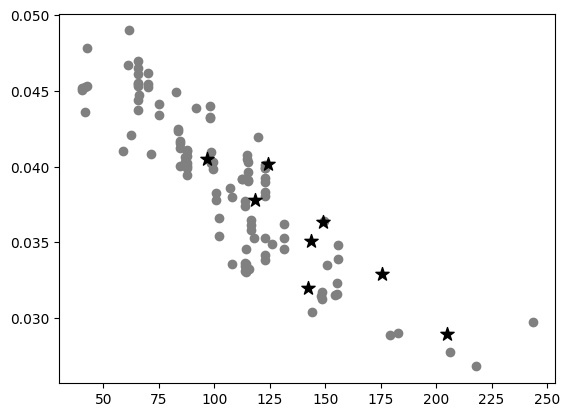

In [89]:
axes_label_fontsize = 18
tick_label_fontsize = 14
text_fontsize = 22
point_size = 90

D_grid = np.linspace(75,200,150)

Mf2_kappa_2T_fig,Mf2_kappa_2T_ax = plt.subplots(1)

for sim in sim_info_core_subeos:
    Mf2_kappa_2T_ax.scatter(sim_info_core_subeos[sim]['D_tilde'],sim_info_core_subeos[sim]['Mfpeak'],color='Grey')

for sim in sim_info_RVSS:
    if sim_info_RVSS[sim]['Mfpeak'] > 0.02:
        Mf2_kappa_2T_ax.scatter(sim_info_RVSS[sim]['D'],sim_info_RVSS[sim]['Mfpeak'],marker='*',s=100,color='Black')

#Mf2_scale_ax.plot(D_grid,D_grid*D_mf2_linregress.slope + D_mf2_linregress.intercept,color='red')
# Mf2_kappa_2T_ax.fill_between(D_for_lin_regress,ci_lower,ci_upper,color='blue')
# Mf2_kappa_2T_ax.set_xlim([0,200])
# Mf2_kappa_2T_ax.set_xlabel(r"$D\left(X,\Psi\right)$",fontsize=axes_label_fontsize)
# Mf2_kappa_2T_ax.set_ylabel(r"$Mf_{\text{pk}}$",fontsize=axes_label_fontsize)
# Mf2_kappa_2T_ax.tick_params(labelsize=tick_label_fontsize)



Nonlinear fitting

In [90]:
def Q_T(x,p1_T,p2_T,p3_T,p4_T):
    return (1 + p1_T*x + p2_T*(x**2))/(1 + p3_T*x + p4_T*(x**2))
def Q_M(nu,a1_m):
    X = 1 - 4*nu
    return 1 + a1_m*X

def Q_fit(data,a0,p1_T,p2_T,p3_T,p4_T,a1_m):
    D_tilde,m1,m2 = data
    nu = (m1*m2)*((m1 + m2)**2)
    return a0*Q_M(nu,a1_m)*Q_T(D_tilde,p1_T,p2_T,p3_T,p4_T)

def Q_sym_fit(x,a0,p1_T,p2_T,p3_T,p4_T):
    return a0*Q_T(x,p1_T,p2_T,p3_T,p4_T)

In [91]:
D_nonlin_fit_sym = D_for_lin_regress_q1
m1_core_sym = np.asanyarray([sim_info_core_subeos[sim]['m1'] for sim in sim_info_core_subeos if sim_info_core_subeos[sim]['m1'] == sim_info_core_subeos[sim]['m2']])
m2_core_sym = m1_core_sym

m1_core_asym = np.asanyarray([sim_info_core_subeos[sim]['m1'] for sim in sim_info_core_subeos if sim_info_core_subeos[sim]['m1'] != sim_info_core_subeos[sim]['m2']])
m2_core_asym = np.asanyarray([sim_info_core_subeos[sim]['m1'] for sim in sim_info_core_subeos if sim_info_core_subeos[sim]['m1'] != sim_info_core_subeos[sim]['m2']])

m1_rvss = np.asanyarray([sim_info_RVSS[sim]['m'] for sim in sim_info_RVSS if sim_info_RVSS[sim]['Mfpeak'] > 0.020])
m2_rvss = m1_rvss
D_nonlin_fit_asym = D_for_lin_regress_asym

D_tot = np.concatenate([D_nonlin_fit_sym,D_nonlin_fit_asym])
mf2_tot = np.concatenate([Mf2_for_lin_regress_q1,Mf2_for_lin_regress_asym])
m1_tot = np.concatenate((m1_core_sym,m1_rvss,m1_core_asym))
m2_tot = np.concatenate((m2_core_sym,m2_rvss,m2_core_asym))

In [92]:
popt_q1,pcov_q1 = curve_fit(Q_sym_fit,D_nonlin_fit_sym,Mf2_for_lin_regress_q1,p0 = [1.0,1.0,1.0,1.0,1.0],maxfev=10000,bounds=([0,0,0,0,0],[np.inf,np.inf,np.inf,np.inf,np.inf]))
a0_sym,p1_T_sym,p2_T_sym,p3_T_sym,p4_T_sym = popt_q1
mf2_pred_sym = Q_sym_fit(D_nonlin_fit_sym,a0_sym,p1_T_sym,p2_T_sym,p3_T_sym,p4_T_sym)
r2_sym = r2_score(Mf2_for_lin_regress_q1,mf2_pred_sym)

print(r2_sym)


0.8421574165896281


In [93]:
popt_tot,pcov_tot = curve_fit(Q_fit,(D_tot,m1_tot,m2_tot),mf2_tot,p0 = [1.0,0.5,1.0,1.0,1.0,1.0],maxfev=10000,bounds=([0,0,0,0,0,0],[np.inf,np.inf,np.inf,np.inf,np.inf,np.inf]))
a0,p1_T,p2_T,p3_T,p4_T,a1_M = popt_tot
mf2_pred = Q_fit((D_tot,m1_tot,m2_tot),a0,p1_T,p2_T,p3_T,p4_T,a1_M)
r2_tot = r2_score(mf2_tot,mf2_pred)

print(r2_tot)

0.7966462715998515


In [32]:
n_boot = 8000
boot_preds = np.zeros((n_boot,100))  # x_fit = points where you want the band
D_data = D_tot_arr
residuals = mf2_tot - Q_sym_fit(D_data, *popt_q1)
D_fit = (np.linspace(min(D_tot_arr),max(D_tot_arr),100))
for i in range(n_boot):
    print(i)
    # Residual bootstrap (recommended)
    boot_residuals = np.random.choice(residuals, size=len(residuals), replace=True)
    y_boot = Q_sym_fit(D_data, *popt_q1) + boot_residuals
    
    try:
        p_boot, _ = curve_fit(Q_sym_fit, D_data, y_boot, p0=popt_q1, maxfev=5000,method='trf')
        boot_preds[i] = Q_sym_fit(D_fit, *p_boot)
    except RuntimeError:
        continue  # skip failed fits

# Confidence band (e.g. 95%)
lower = np.percentile(boot_preds, 5.0, axis=0)
upper = np.percentile(boot_preds, 95.0, axis=0)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [33]:
mf2_rel_diff = (mf2_tot-mf2_pred)/(mf2_tot)
mf2_symm_diff = (Mf2_for_lin_regress_q1 - mf2_pred_sym)/(Mf2_for_lin_regress_q1)

upper_CB = np.empty_like(D_fit)
lower_CB = np.empty_like(D_fit)
q_1_pred = Q_sym_fit(D_fit,*popt_q1)

for i,y in enumerate(q_1_pred):
    upper_CB[i] = (upper[i] - q_1_pred[i])/(q_1_pred[i])
    lower_CB[i] = (lower[i] - q_1_pred[i])/(q_1_pred[i])


In [42]:
def map_to_cbar(val,vmin,vmax,cmap_name = 'viridis'):
    norm = colors.Normalize(vmin=1.0,vmax=2.0)
    cmap = cm.get_cmap(cmap_name)
    rgba_color = cmap(norm(val))

    return rgba_color

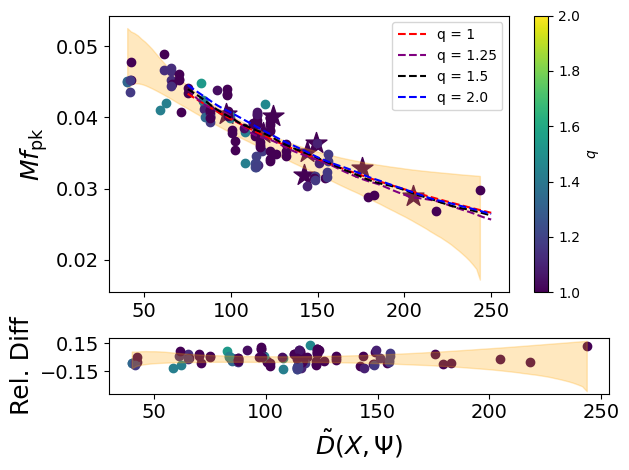

In [50]:
axes_label_fontsize = 18
tick_label_fontsize = 14
text_fontsize = 22
point_size = 250
q1 = 1.25
q2 = 1.5
q3 = 2.0
cmap = 'viridis'
m1_grid_q1 = np.random.normal(loc=np.mean(m1_tot),scale=np.std(m1_tot),size=(1,100))
m2_grid_q1 = m1_grid_q1/q1

m1_grid_q2 = np.random.normal(loc=np.mean(m1_tot),scale=np.std(m1_tot),size=(1,100))
m2_grid_q2 = m1_grid_q2/q2

m1_grid_q3 = np.random.normal(loc=np.mean(m1_tot),scale=np.std(m1_tot),size=(1,100))
m2_grid_q3 = m1_grid_q3/q3

D_grid = np.linspace(75,250,100)
Mf2_grid_q1 = Q_fit((D_grid,m1_grid_q1.flatten(),m2_grid_q1.flatten()),a0,p1_T,p2_T,p3_T,p4_T,a1_M)
Mf2_grid_q2 = Q_fit((D_grid,m1_grid_q2.flatten(),m2_grid_q2.flatten()),a0,p1_T,p2_T,p3_T,p4_T,a1_M)
Mf2_grid_q3 = Q_fit((D_grid,m1_grid_q3.flatten(),m2_grid_q3.flatten()),a0,p1_T,p2_T,p3_T,p4_T,a1_M)


nonlinear_fit_figs,nonlinear_fit_axes = plt.subplots(nrows=2,gridspec_kw={'height_ratios':[5,1]})
nonlinear_fit_ax = nonlinear_fit_axes[0]
rel_dif_ax = nonlinear_fit_axes[1]

for sim in sim_info_RVSS:
    if sim_info_RVSS[sim]['Mfpeak'] > 0.02:
        q = 1.0
        nonlinear_fit_ax.scatter(sim_info_RVSS[sim]['D'],sim_info_RVSS[sim]['Mfpeak'],marker='*',s=point_size,c = q, vmin = 1.0, vmax = 2.0,cmap = cmap)

        mf2_pred = Q_sym_fit(sim_info_RVSS[sim]['D'],*popt_q1)
        mf2_obs = sim_info_RVSS[sim]['Mfpeak']

        rel_dif = (mf2_obs - mf2_pred)/(mf2_obs)
        rel_dif_ax.scatter(sim_info_RVSS[sim]['D'],rel_dif,c = q, vmin = 1.0, vmax = 2.0,cmap = cmap)

Mf2_grid_sym = Q_sym_fit(D_grid,a0_sym,p1_T_sym,p2_T_sym,p3_T_sym,p4_T_sym)
smoothing_spline_q1 = make_smoothing_spline(D_grid,Mf2_grid_q1)
smoothing_spline_q2 = make_smoothing_spline(D_grid,Mf2_grid_q2)
smoothing_spline_q3 = make_smoothing_spline(D_grid,Mf2_grid_q3)

smoothing_spline_sym = make_smoothing_spline(D_grid,Mf2_grid_sym)

mf2_smoothed_q1 = smoothing_spline_q1(D_grid)
mf2_smoothed_q2 = smoothing_spline_q2(D_grid)
mf2_smoothed_q3 = smoothing_spline_q3(D_grid)

mf2_sym_smoothed = smoothing_spline_sym(D_grid)
nonlinear_fit_ax.plot(D_grid,mf2_sym_smoothed,color='red',linestyle='--',label=r"q = 1")
nonlinear_fit_ax.plot(D_grid,mf2_smoothed_q1,color='purple',linestyle='--',label=r"q = 1.25")
nonlinear_fit_ax.plot(D_grid,mf2_smoothed_q2,color='black',linestyle='--',label=r"q = 1.5")
nonlinear_fit_ax.plot(D_grid,mf2_smoothed_q3,color='blue',linestyle='--',label=r"q = 2.0")

nonlinear_fit_ax.fill_between(D_fit,lower,upper,color="orange",alpha=0.25)

for sim in sim_info_core_subeos:
    m1 = sim_info_core_subeos[sim]['m1']
    m2 = sim_info_core_subeos[sim]['m2']
    q = max([m1,m2])/(min([m1,m2]))

    mf2_pred = Q_fit((sim_info_core_subeos[sim]['D_tilde'],m1,m2),*popt_tot)
    mf2_obs = sim_info_core_subeos[sim]['Mfpeak']
    rel_dif = (mf2_obs - mf2_pred)/mf2_pred
    rel_dif_ax.scatter(sim_info_core_subeos[sim]['D_tilde'],rel_dif,c = q, vmin = 1.0,vmax = 2.0,cmap = cmap)
    nonlinear_fit_ax.scatter(sim_info_core_subeos[sim]['D_tilde'],sim_info_core_subeos[sim]['Mfpeak'],c=q,vmin=1.0,vmax=2.0,cmap=cmap)
    
    
    

nonlinear_fit_ax.set_ylabel(r'$Mf_{\text{pk}}$',fontsize=axes_label_fontsize)
nonlinear_fit_ax.tick_params(labelsize=tick_label_fontsize)
nonlinear_fit_ax.legend()


mf2_rel_diff = (mf2_tot-mf2_pred)/(mf2_tot)
mf2_symm_diff = (Mf2_for_lin_regress_q1 - mf2_pred_sym)/(Mf2_for_lin_regress_q1)
rel_dif_ax.fill_between(D_fit,lower_CB,upper_CB,color='orange',alpha=0.25)

rel_dif_ax.set_yticks([-0.15,0.15])
rel_dif_ax.set_xlabel(r'$\tilde{D}(X,\Psi)$',fontsize=axes_label_fontsize)
rel_dif_ax.set_ylabel(r'Rel. Diff',fontsize=axes_label_fontsize)
norm = colors.Normalize(vmin=1.0,vmax=2.0)
sm = cm.ScalarMappable(cmap=cmap,norm=norm)
sm.set_array([])
nonlinear_fit_figs.colorbar(sm,ax=nonlinear_fit_ax,label=r'$q$')
rel_dif_ax.tick_params(labelsize=tick_label_fontsize)
nonlinear_fit_figs.tight_layout()

# nonlinear_fit_figs.savefig('./Figures/Final_Paper_Figs/Mf2_Dtilde_relation.pdf',format='pdf',dpi=300)




In [32]:
kappa_2T_nonlin_fit_sym = kappa_2T_q1
m1_core_sym = np.asanyarray([sim_info_core_subeos[sim]['m1'] for sim in sim_info_core_subeos if sim_info_core_subeos[sim]['m1'] == sim_info_core_subeos[sim]['m2']])
m2_core_sym = m1_core_sym

m1_core_asym = np.asanyarray([sim_info_core_subeos[sim]['m1'] for sim in sim_info_core_subeos if sim_info_core_subeos[sim]['m1'] != sim_info_core_subeos[sim]['m2']])
m2_core_asym = np.asanyarray([sim_info_core_subeos[sim]['m1'] for sim in sim_info_core_subeos if sim_info_core_subeos[sim]['m1'] != sim_info_core_subeos[sim]['m2']])

m1_rvss = np.asanyarray([sim_info_RVSS[sim]['m'] for sim in sim_info_RVSS if sim_info_RVSS[sim]['Mfpeak'] > 0.020])
m2_rvss = m1_rvss

kappa_2T_nonlin_fit_asym = kappa_2T_asym

m1_tot = np.concatenate((m1_core_sym,m1_rvss,m1_core_asym))
m2_tot = np.concatenate((m2_core_sym,m2_rvss,m2_core_asym))

In [ ]:
popt,pcov = curve_fit(Q_sym_fit,kappa_2T_nonlin_fit_sym,Mf2_for_lin_regress_q1,p0 = [1.0,1.0,1.0,1.0,1.0],maxfev=10000,bounds=([0,0,0,0,0],[np.inf,np.inf,np.inf,np.inf,np.inf]))
a0_sym_k,p1_T_sym_k,p2_T_sym_k,p3_T_sym_k,p4_T_sym_k = popt
mf2_pred_sym_k = Q_sym_fit(kappa_2T_nonlin_fit_sym,a0_sym_k,p1_T_sym_k,p2_T_sym_k,p3_T_sym_k,p4_T_sym_k)
r2_sym_k = r2_score(Mf2_for_lin_regress_q1,mf2_pred_sym_k)

print(r2_sym_k)


0.773074572863761


In [36]:
popt_tot,pcov_tot = curve_fit(Q_fit,(D_tot,m1_tot,m2_tot),mf2_tot,p0 = [1.0,0.5,1.0,1.0,1.0,1.0],maxfev=10000,bounds=([0,0,0,0,0,0],[np.inf,np.inf,np.inf,np.inf,np.inf,np.inf]))
a0_k,p1_T_k,p2_T_k,p3_T_k,p4_T_k,a1_M_k = popt_tot
mf2_pred_k = Q_fit((D_tot,m1_tot,m2_tot),a0_k,p1_T_k,p2_T_k,p3_T_k,p4_T_k,a1_M_k)
r2_tot_k = r2_score(mf2_tot,mf2_pred_k)

print(r2_tot_k)

0.6921686751850553
